EEG-Based Emotion Recognition using StressNet from 
https://www.kaggle.com/code/enriquearanda4/bci-project/edit 
They most likely built this using AI but I think it's interesting to explore these methods.

In [58]:
# StressNet (CNN + LSTM + Fusion)

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import gc
import multiprocessing
import seaborn as sns
import mne # visualize EEG 

from tqdm import tqdm
from joblib import Parallel, delayed

from scipy.signal import butter, filtfilt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf 
from tensorflow.keras import layers, models, callbacks, Input, Model 
from tensorflow.keras.optimizers import Adam

In [75]:
# Load SEED data
def load_seed(folder ='../../backend/data/SEED_dataset/'):
    """ Load SEED dataset: returns (N, channels, time), labels, subject IDs """
    eeg = np.load(os.path.join(folder, 'DatasetCaricatoNoImage.npz'))['arr_0']
    lab = np.load(os.path.join(folder, 'LabelsNoImage.npz'))['arr_0']
    subj = np.load(os.path.join(folder, 'SubjectsNoImage.npz'))['arr_0']
    return eeg, lab, subj

eeg_all, labels_all, subject_idx = load_seed('../../backend/data/SEED_dataset/')
print("Raw EEG shape: ", eeg_all.shape) # (n_trials, time, channels)
print("Labels shape: ", labels_all.shape)
subject_count =np.unique(subject_idx).size
print("Subjects: ", subject_count)
print(f"Time dimension: {eeg_all.shape[1]}, channels: {eeg_all.shape[2]}")

# 5 bands: delta, theta, alpha, beta, gamma
is_bandpassed = (eeg_all.shape[1]==5)
print(f"Data is pre-processed frequency bands: {is_bandpassed}")

Raw EEG shape:  (50910, 5, 62)
Labels shape:  (50910,)
Subjects:  15
Time dimension: 5, channels: 62
Data is pre-processed frequency bands: True


In [60]:
# Stress Label
# from kaggle notebook, though negative doesn't necessarily mean stress
# binary task: stress(negative=0) vs. nonstress(neutral/positive = 1)
#SEED labels: 0= negative, 1= neutral, 2= positive
print("Unique labels: ", np.unique(labels_all))
print("Raw label counts: ", np.bincount(labels_all))


y= (labels_all).astype(int)
print("Class distribution (binary): ", np.bincount(y) )

print("0 = Stress (negative)")
print("1 = Non-stress (neutral or positive)")

Unique labels:  [0 1 2]
Raw label counts:  [16800 16560 17550]
Class distribution (binary):  [16800 16560 17550]
0 = Stress (negative)
1 = Non-stress (neutral or positive)


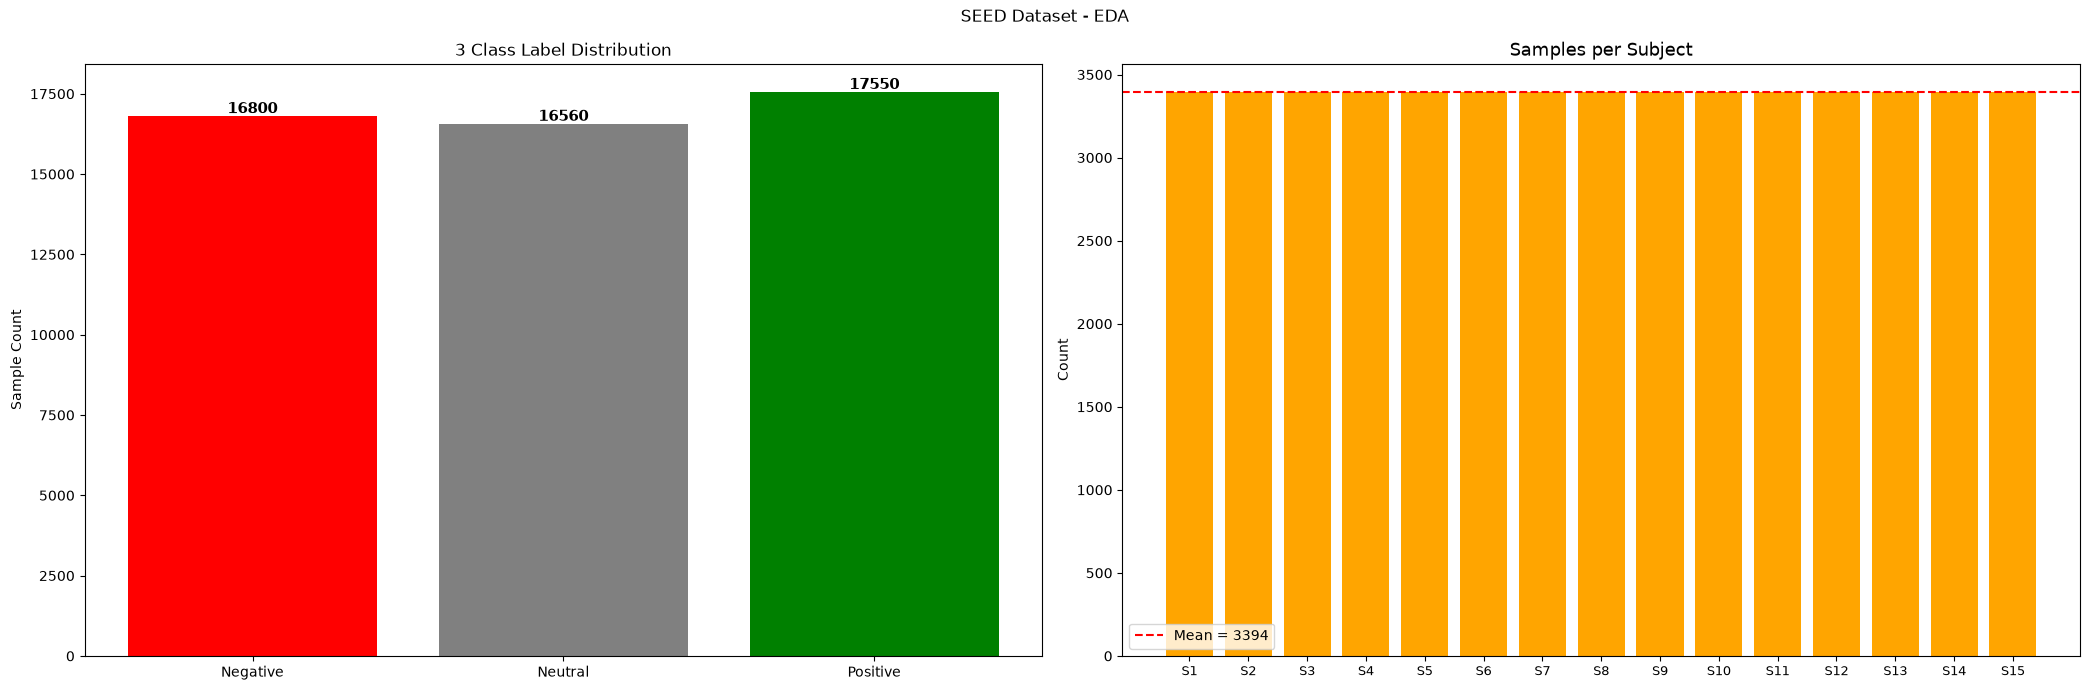

In [61]:
# EDA, label distribution

fig, axes= plt.subplots(1,2, figsize=(21,7))

#class balance for stress
# counts = np.bincount(y)
# axes[0].bar(['Stress (0)', 'Non-Stress (1)'], counts)
# for i, c in enumerate(counts):
#     axes[0].text(i,c +200,str(c), ha='center', fontweight='bold')
# axes[0].set_title('Binary Class Distribution')
# axes[0].set_ylabel('Sample Count')

#original 3-class distribution
orig_counts = np.bincount(labels_all)
axes[0].bar(['Negative', 'Neutral', 'Positive'], orig_counts, color = ['red','gray','green'])
for i, c in enumerate(orig_counts):
    # little number on top
    axes[0].text(i, c + 100, str(c), ha='center',fontweight='bold', fontsize=11)
axes[0].set_title('3 Class Label Distribution')
axes[0].set_ylabel('Sample Count')

# per subject sample count
subj_sample_counts=[int((subject_idx == s).sum()) for s in range(subject_count)]
axes[1].bar(range(subject_count), subj_sample_counts, color='orange')
axes[1].axhline(np.mean(subj_sample_counts), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(subj_sample_counts):.0f}')
axes[1].set_xticks(range(subject_count))
axes[1].set_xticklabels([f'S{i+1}' for i in range(subject_count)], fontsize=9)
axes[1].set_title('Samples per Subject', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('SEED Dataset - EDA')
plt.tight_layout()
plt.show()

/var/folders/46/yc4496mx77g8716fqwx2phsr0000gn/T/ipykernel_9422/475860522.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(band_names, fontsize=9)


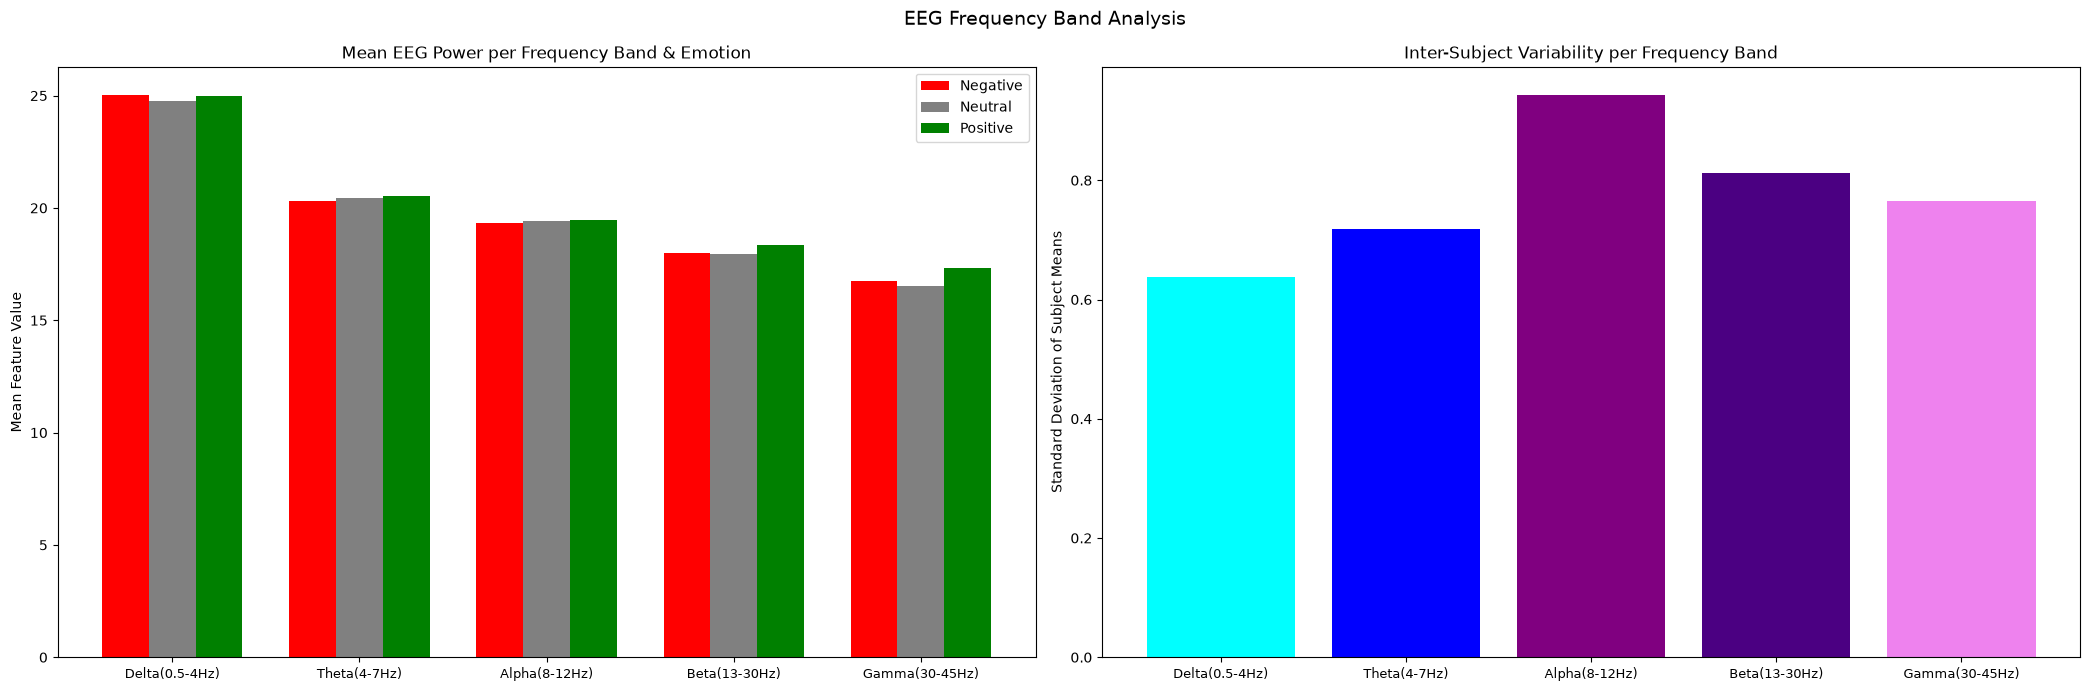

In [62]:
# EDA, frequency band power analysis
# dataset is organized as (N, 5, 62):
# axis 1 = 5 frequency bands 
# axis 2 = 62 EEG Channels

# visualize mean band power per emotion class

band_names = ['Delta(0.5-4Hz)', 'Theta(4-7Hz)', 'Alpha(8-12Hz)', 'Beta(13-30Hz)', 'Gamma(30-45Hz)']
emotion_labels=['Negative', 'Neutral', 'Positive']
emotion_colors = ['red','gray','green']

fig, axes = plt.subplots(1,2, figsize=(21,7))

# mean band power per emotion
x = np.arange(5)
w = 0.25
for ei, (en,ec) in enumerate(zip(emotion_labels, emotion_colors)):
    mask = labels_all == ei
    # eeg_all shape: (N, 5, 62) - mean over all channels and samples
    mean_power = eeg_all[mask].mean(axis=0).mean(axis=1) # (5,)
    axes[0].bar(x+(ei-1)*w, mean_power, width=w, label=en, color=ec, linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(band_names, fontsize=9)
axes[0].set_ylabel('Mean Feature Value')
axes[0].set_title('Mean EEG Power per Frequency Band & Emotion', fontsize=12)
axes[0].legend()

# band power variance across subjects

var_per_band = []
for si in range(5):
    subject_means = [eeg_all[subject_idx==s, si, :].mean() for s in range(subject_count)]
    var_per_band.append(np.std(subject_means))
axes[1].bar(band_names, var_per_band, color = ['cyan','blue','purple','indigo','violet'])
axes[1].set_ylabel('Standard Deviation of Subject Means')
axes[1].set_title('Inter-Subject Variability per Frequency Band', fontsize=12)
axes[1].set_xticklabels(band_names, fontsize=9)

plt.suptitle('EEG Frequency Band Analysis', fontsize=14)
plt.tight_layout()
plt.show()

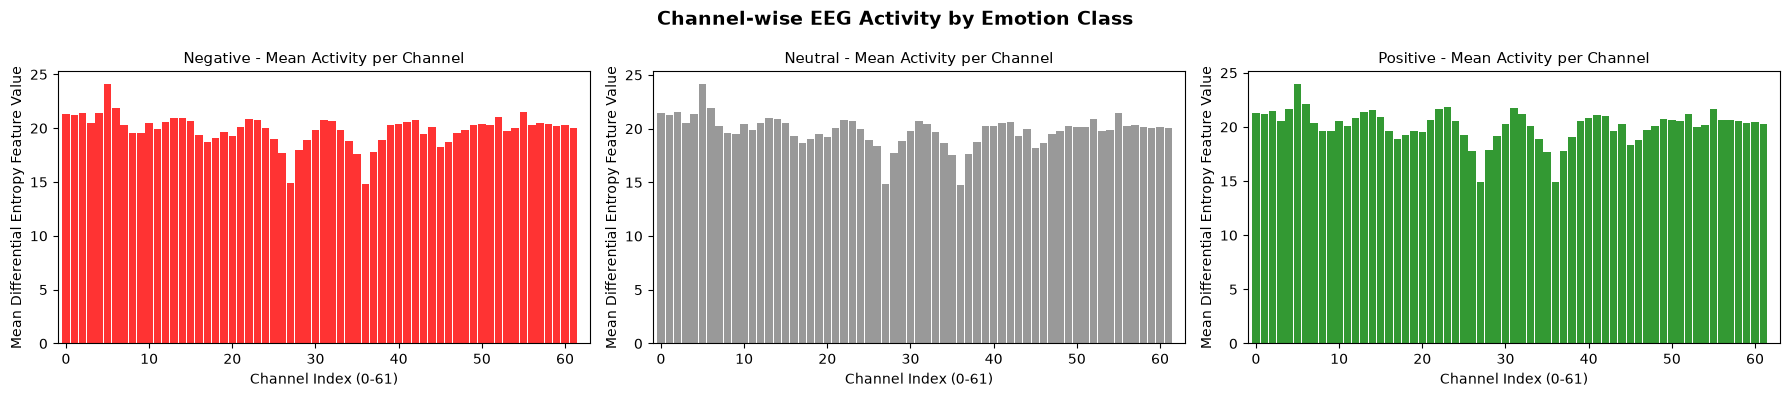

In [63]:
# EDA, channel-wise activity heatmap
channel_count = eeg_all.shape[2]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ei, (en, ec) in enumerate(zip(emotion_labels, emotion_colors)):
    mask = labels_all == ei
    # Mean across all bands --> (62,) - one value per channel
    ch_activity = eeg_all[mask].mean(axis=0).mean(axis=0) # (62,)
    axes[ei].bar(range(channel_count), ch_activity, color=ec, alpha=0.8, width=0.9)
    axes[ei].set_title(f'{en} - Mean Activity per Channel', fontsize=11)
    axes[ei].set_xlabel('Channel Index (0-61)')
    axes[ei].set_ylabel('Mean Differential Entropy Feature Value')
    axes[ei].set_xlim(-1,63)
plt.suptitle('Channel-wise EEG Activity by Emotion Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

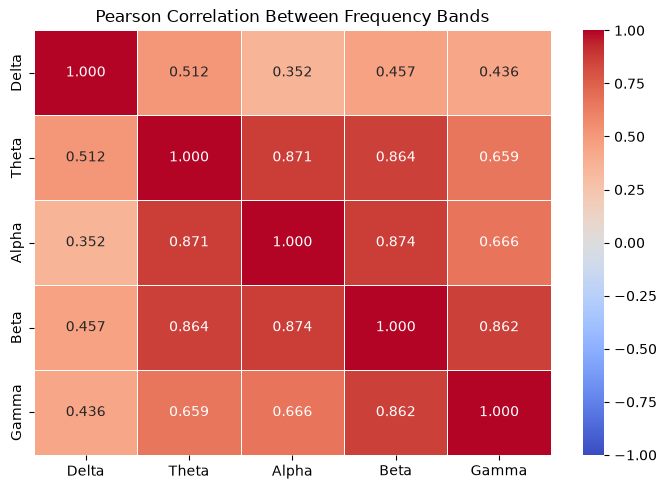

In [64]:
# EDA, correlation between frequency bands

# compute correlation matrix between band-averaged features
band_data = eeg_all.mean(axis=2) # (N, 5) - avg over channels
band_df = pd.DataFrame(band_data, columns=['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])

plt.figure(figsize=(7,5))
sns.heatmap(band_df.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin = -1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation Between Frequency Bands')
plt.tight_layout()
plt.show()

Missing channels (Fibonacci-placed):  ['FP1', 'FPZ', 'FP2', 'FZ', 'FCZ', 'CZ', 'CPZ', 'PZ', 'POZ', 'CB1', 'OZ', 'CB2']


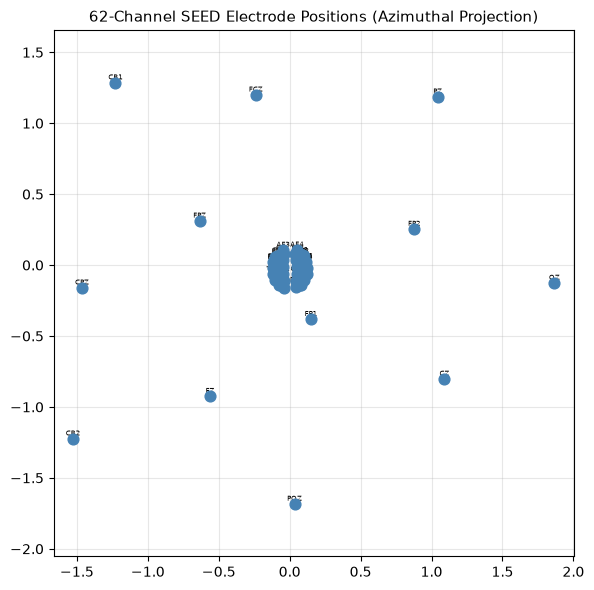

Electrode positions computed for 50 channels.


In [65]:
# Signal Preprocessing

# Channel Positions
seed_62 = [
    'FP1','FPZ','FP2','AF3','AF4','F7','F5','F3','F1','FZ','F2','F4','F6','F8',
    'FT7','FC5','FC3','FC1','FCZ','FC2','FC4','FC6','FT8','T7','C5','C3','C1',
    'CZ','C2','C4','C6','T8','TP7','CP5','CP3','CP1','CPZ','CP2','CP4','CP6',
    'TP8','P7','P5','P3','P1','PZ','P2','P4','P6','P8','PO7','PO5','PO3',
    'POZ','PO4','PO6','PO8','CB1','O1','OZ','O2','CB2'
]

montage= mne.channels.make_standard_montage('standard_1020')
pos = montage.get_positions()['ch_pos']
pos_seed = {ch.upper(): pos[ch.upper()] for ch in seed_62 if ch.upper() in pos}
missing = [c for c in seed_62 if c.upper() not in pos_seed]
print("Missing channels (Fibonacci-placed): ", missing)

def fibonacci_sphere(n):
    i = np.arange(n)+0.5
    phi = np.arccos(1-2*i/n)
    theta=np.pi * (1+5**0.5) * i
    return np.sin(phi)*np.cos(theta), np.sin(phi)*np.sin(theta), np.cos(phi)

Xfb, Yfb, Zfb = fibonacci_sphere(len(missing))
k_fb = np.sqrt(2.0 / (1.0 + Zfb))
u_fb= (k_fb * Xfb).astype(float)
v_fb = (k_fb * Yfb).astype(float)

u_ch = np.zeros(channel_count)
v_ch = np.zeros(channel_count)

for i, ch in enumerate(seed_62):
    if ch.upper() in pos_seed:
        xyz = pos_seed[ch.upper()]
        k = np.sqrt(2.0 / (1.0 + xyz[2]))
        u_ch[i] = k * xyz[0]
        v_ch[i] = k * xyz[1]
    else: 
        idx = missing.index(ch)
        u_ch[i] = u_fb[idx]
        v_ch[i] = v_fb[idx]

# Visualize electrode positions

plt.figure(figsize=(6,6))
plt.scatter(u_ch, v_ch, c='steelblue', s=60, zorder=5)
for i, ch in enumerate(seed_62):
    plt.text(u_ch[i], v_ch[i]+0.01, ch, fontsize=5, ha='center', va='bottom')
plt.title('62-Channel SEED Electrode Positions (Azimuthal Projection)', fontsize=11)
plt.axis('equal')
plt.grid(True, alpha =0.3)
plt.tight_layout()
plt.show()
print(f"Electrode positions computed for {len(pos_seed)} channels.")

In [66]:
# Bandpass filtering 

eeg_for_band = np.transpose(eeg_all, (0,2,1)) # N, time=62, ch=5
sf = 200
bands= {'delta':(0.5,4), 'theta':(4,7), 'alpba':(8,12), 'beta':(13,30), 'gamma':(30,45)}
img_size=64

def _butter(low, high, fs, order=2):
    nyq = 0.5*fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return b, a

def _bandpass(eeg_3d, bname):
    lo, hi = bands[bname]
    b, a = _butter(lo, hi, sf)
    sig_len = eeg_3d.shape[-1]
    padlen = min(sig_len // 2 - 1, 27)
    if padlen < 1 or sig_len < 3:
        return eeg_3d.astype(np.float32)
    try: 
        return filtfilt(b, a, eeg_3d, axis=-1, padlen=padlen).astype(np.float32)
    except ValueError:
        return eeg_3d.astype(np.float32)


#azimutahal topographic images (64x64x5)

u_grid = np.linspace(u_ch.min(), u_ch.max(), img_size)
v_grid = np.linspace(v_ch.min(), v_ch.max(), img_size)
UU, VV = np.meshgrid(u_grid, v_grid)
tree = cKDTree(np.column_stack((u_ch, v_ch)))


def sample_to_topomap(vals, sigma=1.0):
    if np.any(np.isnan(vals)) or np.std(vals) < 1e-8:
        vals = np.nan_to_num(vals, nan=0.0)
    grid = griddata(np.column_stack((u_ch, v_ch)), vals,
                    (UU, VV), method='cubic')
    nan_mask = np.isnan(grid)
    if nan_mask.any():
        try: 
            idx = tree.query(np.column_stack((UU.ravel()[nan_mask], VV.ravel()[nan_mask])))[1]
            grid.ravel()[nan_mask] = vals[idx]
        except:
            grid[nan_mask] = 0.0
    grid = gaussian_filter(grid, sigma=sigma)
    mn, mx = grid.min(), grid.max()
    grid = (grid-mn)/(mx-mn) if mx - mn > 1e-8 else np.zeros_like(grid)
    return np.clip(grid, 0, 1).astype(np.float32)

def gen_one_image(i, eeg_sample):
    out = np.zeros((img_size, img_size, len(bands)), dtype=np.float32)
    for b_idx, bname in enumerate(bands):
        filt = _bandpass(eeg_sample[np.newaxis, :, :], bname)[0]
        vals = np.mean(np.abs(filt), axis=1)
        out[..., b_idx] = sample_to_topomap(vals)
    return out


n_jobs = min(multiprocessing.cpu_count() -1, 8)
print("Generating 64x64x5 topograhic images ...")
imgs = Parallel(n_jobs=n_jobs)(
    delayed(gen_one_image)(i, eeg_for_band[i])
    for i in tqdm(range(eeg_for_band.shape[0]))
)
images = np.stack(imgs)
print("Images shape: ", images.shape) # (50910, 64, 64, 5)
del imgs, eeg_for_band
gc.collect()

Generating 64x64x5 topograhic images ...


100%|██████████| 50910/50910 [01:14<00:00, 686.27it/s]


Images shape:  (50910, 64, 64, 5)


27

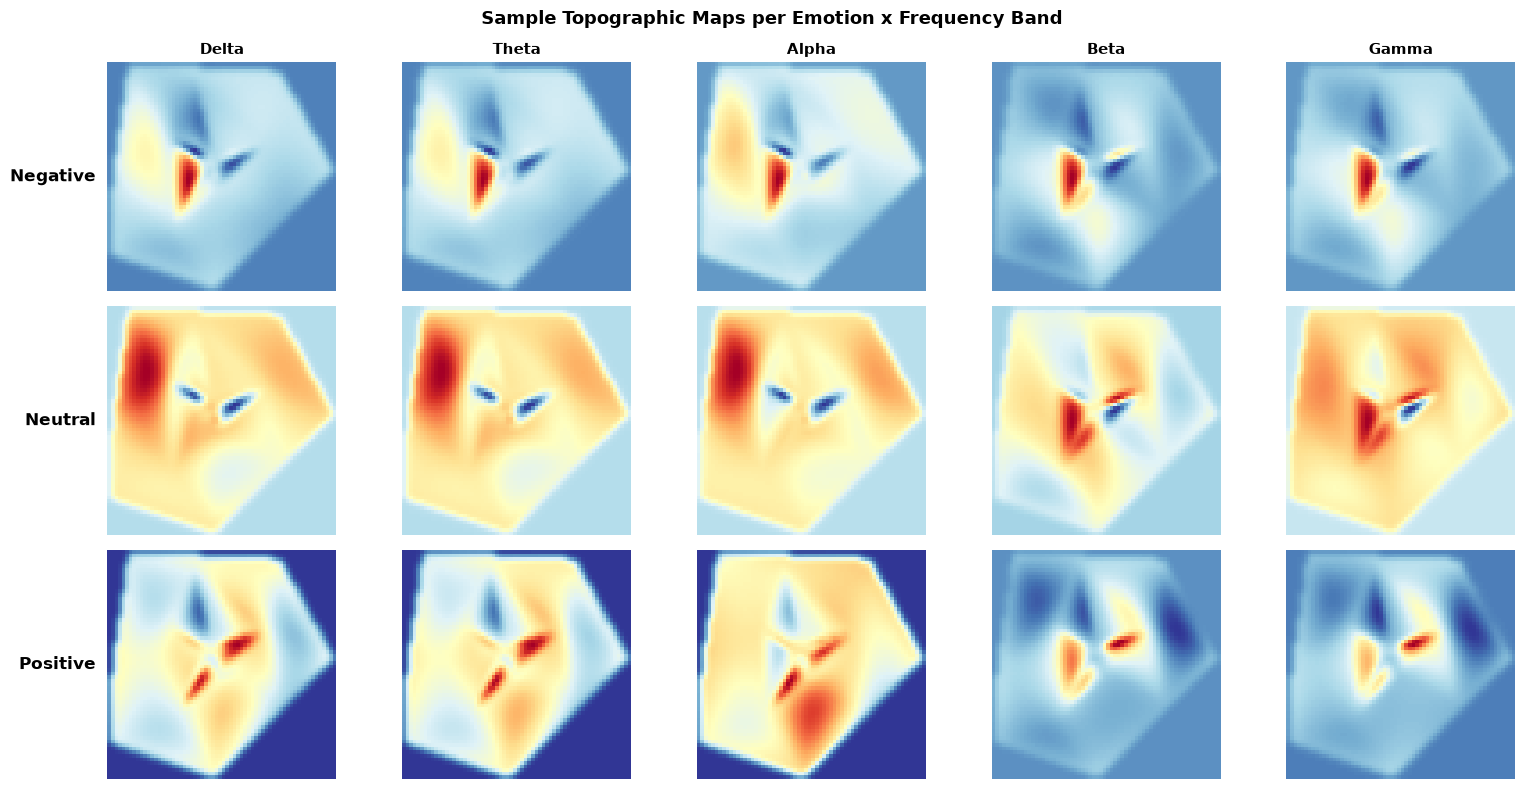

Each row is one emotion class, each column is one frequency band
Color: red = high activity, blue = low activity


In [67]:
# Visualize sample topographic images : one per emotion class
# reminder the person who originally made this notebook used AI
# there's documentation somewhere on how to implement all this

#renaming band_names to omit frequencies
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

fig, axes = plt.subplots(3, 5, figsize = (16,8))
for ei, en in enumerate(emotion_labels):
    sample_idx = np.where(labels_all == ei)[0][42] # representative sample
    for bi in range(len(band_names)):
        ax=axes[ei, bi]
        im = ax.imshow(images[sample_idx, :, :, bi], cmap = 'RdYlBu_r', origin = 'lower', vmin=0, vmax=1)
        ax.axis('off')
        if ei == 0: 
            ax.set_title(band_names[bi], fontsize=11, fontweight='bold')
        if bi==0:
            # gemin-generated line: ax.text works (x pos, y pos, label, overall position?, text styling, .. ... )
            ax.text(-0.05, 0.5, en, transform=ax.transAxes, fontsize=12, fontweight='bold', va='center', ha='right')
plt.suptitle('Sample Topographic Maps per Emotion x Frequency Band', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each row is one emotion class, each column is one frequency band")
print("Color: red = high activity, blue = low activity")



In [72]:
# Data Splitting + Normalization

# we create clean train/val/test splits before fitting any normalization scaler to prevent data leakage from test set into training statistics

# Train: 64%, Validation 16%, Test: 20%
# scaler is fit only on training data, then applied to val and test

#Downsample and create splits

down_factor = 8 if eeg_all.shape[0] > 1000 else 1 # doesn't really make sense because it's number of channels, so i changed it from 2 to 0
eeg_down = eeg_all[::down_factor,:,:] # ::down_factor means to divide size by down_factor
labels_down = labels_all[::down_factor] # need to also be downsized < v
subject_idx_down = subject_idx[::down_factor]
print("EEG Shape after downsampling: ", eeg_down.shape)
print(f"Downsampling factor used: {down_factor}") # nothing changed if 1

y_down = y[::down_factor]
images_down = images[::down_factor, :, :, :]

# normalize images per sample
for i in range(images_down.shape[0]):
    im = images_down[i]
    mn = im.min()
    mx = im.max()
    if mx-mn > 1e-8:
        images_down[i] = (im-mn) / (mx-mn)

# Deterministic stratified splits
idx = np.arange(len(y_down))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y_down, random_state=42)
train_idx, val_idx= train_test_split(train_idx, test_size=0.2, stratify=y_down[train_idx], random_state=42)

eeg_train, eeg_val, eeg_test = eeg_down[train_idx], eeg_down[val_idx], eeg_down[test_idx]
img_train, img_val, img_test = images_down[train_idx], images_down[val_idx], images_down[test_idx]

y_train, y_val, y_test = y_down[train_idx], y_down[val_idx], y_down[test_idx]

# Fit scaler ONLY on train so that there's no leakage

scaler_eeg = StandardScaler().fit(eeg_train.reshape(-1, eeg_train.shape[-1]))

def scale_split(X, sc):
    flat = X.reshape(-1, X.shape[-1])
    return sc.transform(flat).reshape(X.shape)

X_train_e = scale_split(eeg_train, scaler_eeg)
X_val_e = scale_split(eeg_val, scaler_eeg)
X_test_e = scale_split(eeg_test, scaler_eeg)

X_train_i, X_val_i, X_test_i = img_train, img_val, img_test

# Save splits

for name, arr in [('X_train_i', X_train_i), ('X_val_i', X_val_i), ('X_test_i', X_test_i), ('X_train_e', X_train_e), 
('X_val_e', X_val_e), ('X_test_e', X_test_e), ('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
                  np.save(f'../data/eeg_emotion_recognition_data/{name}.npy', arr.astype(np.float32 if 'y' not in name else np.int32))
                

print(f'\nSplit Summary:')
print(f"Train: {len(y_train):6d} samples | class dist: {np.unique(y_train, return_counts=True)}")
print(f"Validation: {len(y_val):6d} samples | class dist: {np.unique(y_val, return_counts=True )}")
print(f"Test Split: {len(y_test):6d} samples | class dist: {np.unique(y_test, return_counts=True)}")

print(f"EEG shape (train): {X_train_e.shape}")
print(f"Image shape (train): {X_train_i.shape}")

EEG Shape after downsampling:  (6364, 5, 62)
Downsampling factor used: 8

Split Summary:
Train:   4072 samples | class dist: (array([0, 1, 2]), array([1347, 1323, 1402]))
Validation:   1019 samples | class dist: (array([0, 1, 2]), array([337, 331, 351]))
Test Split:   1273 samples | class dist: (array([0, 1, 2]), array([421, 413, 439]))
EEG shape (train): (4072, 5, 62)
Image shape (train): (4072, 64, 64, 5)


In [84]:
# Load Splits and Verify

X_train_i = np.load('../data/eeg_emotion_recognition_data/X_train_i.npy')
X_val_i = np.load('../data/eeg_emotion_recognition_data/X_val_i.npy')
X_test_i = np.load('../data/eeg_emotion_recognition_data/X_test_i.npy')

X_train_e = np.load('../data/eeg_emotion_recognition_data/X_train_e.npy')
X_val_e = np.load('../data/eeg_emotion_recognition_data/X_val_e.npy')
X_test_e = np.load('../data/eeg_emotion_recognition_data/X_test_e.npy')

y_train = np.load('../data/eeg_emotion_recognition_data/y_train.npy')
y_val = np.load('../data/eeg_emotion_recognition_data/y_val.npy')
y_test = np.load('../data/eeg_emotion_recognition_data/y_test.npy')


# EEG input to LSTM must be (N, time_steps, channels)

print("EEG Shapes\nTrain: ", X_train_e.shape, "\nValidation: ", X_val_e.shape, "\nTest: ", X_test_e.shape)

EEG Shapes
Train:  (4072, 5, 62) 
Validation:  (1019, 5, 62) 
Test:  (1273, 5, 62)


In [85]:
# Model Architecture Definitions

# for now just lstm

def lstm_branch(time_steps, n_ch):
    inp = Input(shape=(time_steps, n_ch), name='eeg_input')
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)
    )(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False, dropout=0.4, recurrent_dropout=0.4)
    )(x)
    x = layers.Dropout(0.4)(x)
    feat = layers.Dense(128, activation='relu', name='lstm_feat')(x)
    return inp, feat


In [89]:
# train just lstm model

lstm_in, lstm_feat = lstm_branch(X_train_e.shape[1], X_train_e.shape[2])
lstm_out = layers.Dense(3, activation='softmax')(layers.Dense(128, activation='relu')(lstm_feat))
lstm = Model(lstm_in, lstm_out)
lstm.compile(Adam(1e-4), 'sparse_categorical_crossentropy', metrics=['accuracy'])

rng= np.random.RandomState(42)

X_train_noisy = X_train_e + rng.normal(0,0.02,X_train_e.shape)

cw_vals = compute_class_weight(class_weight = 'balanced', classes=np.unique(y_train), y=y_train)
lstm_history = lstm.fit(X_train_noisy, y_train, validation_data=(X_val_e, y_val), epochs=40,
batch_size=32, class_weight=dict(enumerate(cw_vals)),
    callbacks=[callbacks.EarlyStopping(patience=8, restore_best_weights=True),
               callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-7),
               callbacks.ModelCheckpoint('../data/eeg_emotion_recognition_data/best_lstm.keras', save_best_only=True)],
    verbose=1)

Epoch 1/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4005 - loss: 1.0856 - val_accuracy: 0.5270 - val_loss: 1.0444 - learning_rate: 1.0000e-04
Epoch 2/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5025 - loss: 1.0007 - val_accuracy: 0.5790 - val_loss: 0.8503 - learning_rate: 1.0000e-04
Epoch 3/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5513 - loss: 0.8817 - val_accuracy: 0.6330 - val_loss: 0.7714 - learning_rate: 1.0000e-04
Epoch 4/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5941 - loss: 0.8205 - val_accuracy: 0.6094 - val_loss: 0.7554 - learning_rate: 1.0000e-04
Epoch 5/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6034 - loss: 0.8067 - val_accuracy: 0.6565 - val_loss: 0.6796 - learning_rate: 1.0000e-04
Epoch 6/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6036 - loss: 0.7790 - val_accuracy: 0.6536 - val_loss: 0.6566 - learning_rate: 1.0000e-04
Epoch 7/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - ac